<a href="https://colab.research.google.com/github/SAISANJAYR/Sai-s_IQube_Practice_Tasks/blob/main/Sai's_IQube_Practice_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sai's IQube Practice-Notebook**

## 1. **Day-1** (*Types of Data & Descriptive Statistics*)

**Task:** Create a list of 8–10 student exam scores. Manually compute the mean, median, mode,
variance, and standard deviation. Then verify your results using NumPy and SciPy. Finally, add
an extreme outlier (e.g., 0 or 100) and observe how each measure changes.

In [ ]:
student_marks = [70, 83, 86, 71, 97, 76, 86]

mean = sum(student_marks)/len(student_marks)
print(f"Mean of the marks (manual calc): {mean}\n")

sorted_marks = sorted(student_marks)
if len(student_marks) % 2 != 0:
  median = sorted_marks[len(student_marks)//2]
else:
  median = (sorted_marks[len(student_marks)//2 - 1] + sorted_marks[len(student_marks)//2])/2
print(f"Median of the marks (manual calc): {median}\n")

# Recalculate mean as student_marks is now sorted and might be used for other calculations
# if using in-place sort, but with sorted(), student_marks remains original
# For variance, n should be defined as the number of elements
n = len(student_marks)
var_sum = sum([(x - mean)**2 for x in student_marks])
variance = var_sum/n
print(f"Variance of the marks (manual calc): {variance}\n")

std_deviation = variance**(1/2)
print(f"Standard deviation of the marks (manual calc): {std_deviation}\n")

Mean of the marks (manual calc): 81.28571428571429

Median of the marks (manual calc): 83

Variance of the marks (manual calc): 79.34693877551021

Standard deviation of the marks (manual calc): 8.907689867497083



In [ ]:
import numpy as np
import scipy as sp

mean_np = np.mean(student_marks)
print(f"Mean of the marks (np): {mean_np}\n")

median_np = np.median(student_marks)
print(f"Median of the marks (np): {median_np}\n")

variance_np = np.var(student_marks)
print(f"Variance of the marks (np): {variance_np}\n")

std_dev_np = np.std(student_marks)
print(f"Standard deviation of the marks (np): {std_dev_np}\n")

Mean of the marks (np): 81.28571428571429

Median of the marks (np): 83.0

Variance of the marks (np): 79.34693877551021

Standard deviation of the marks (np): 8.907689867497083



## 2. **Day-2** (*Probability Fundamentals*)

**Task:** Visualize the binomial distribution using matplotlib for different values of n (10, 20, 50) and p
(0.2, 0.5, 0.8). Place all 9 combinations in a 3×3 grid subplot. Observe: When does the
distribution look symmetric? When is it skewed? What happens as n increases?

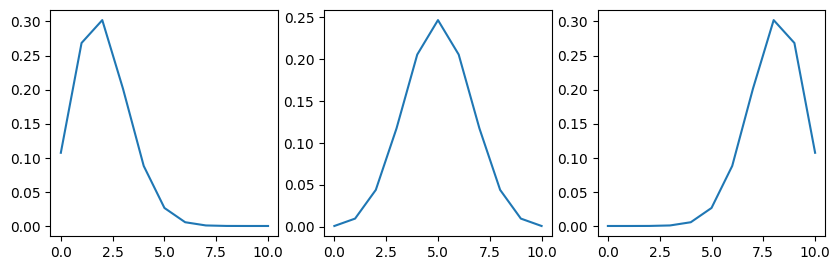

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import binom

plt.figure(figsize=(10, 10))

n1, p1 = 10, 0.2
pmf = binom.pmf(range(n1 + 1), n1, p1)
plt.subplot(3, 3, 1)
plt.plot(range(n1+1), pmf)

p2 = 0.5
pmf = binom.pmf(range(n1 + 1), n1, p2)
plt.subplot(3, 3, 2)
plt.plot(range(n1+1), pmf)

p3 = 0.8
pmf = binom.pmf(range(n1 + 1), n1, p3)
plt.subplot(3, 3, 3)
plt.plot(range(n1+1), pmf)



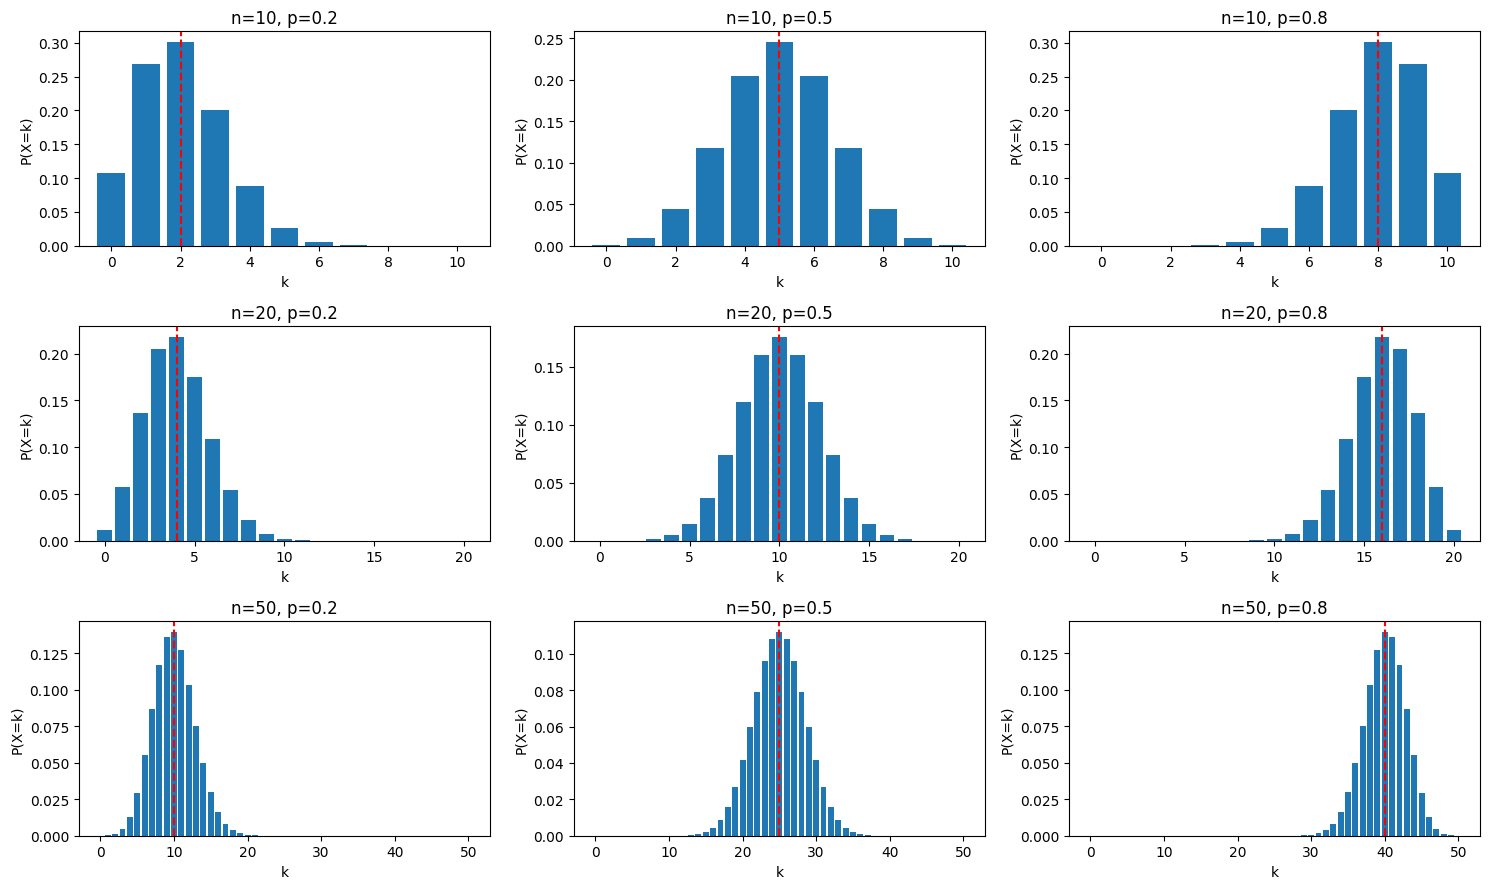

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n_values = [10, 20, 50]
p_values = [0.2, 0.5, 0.8]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))

for i, n in enumerate(n_values):
    for j, p in enumerate(p_values):
        ax = axes[i, j]

        x = np.arange(0, n + 1)
        pmf = binom.pmf(x, n, p)

        ax.bar(x, pmf)

        mean = n * p
        ax.axvline(mean, color = 'red', linestyle='--')

        ax.set_title(f'n={n}, p={p}')
        ax.set_xlabel('k')
        ax.set_ylabel('P(X=k)')

plt.tight_layout()
plt.show()

## 3. **Day-3** *(Normal Distribution & Sampling)*

**Task:** Simulate the Central Limit Theorem: Generate a population from an exponential distribution
(heavily right-skewed). Draw 1000 samples each of size n=5, n=15, and n=30. Plot the
distribution of sample means for each. Watch the normal bell curve emerge as n increases!

Text(0.5, 1.0, 'Sample Mean Distribution (n=30)')

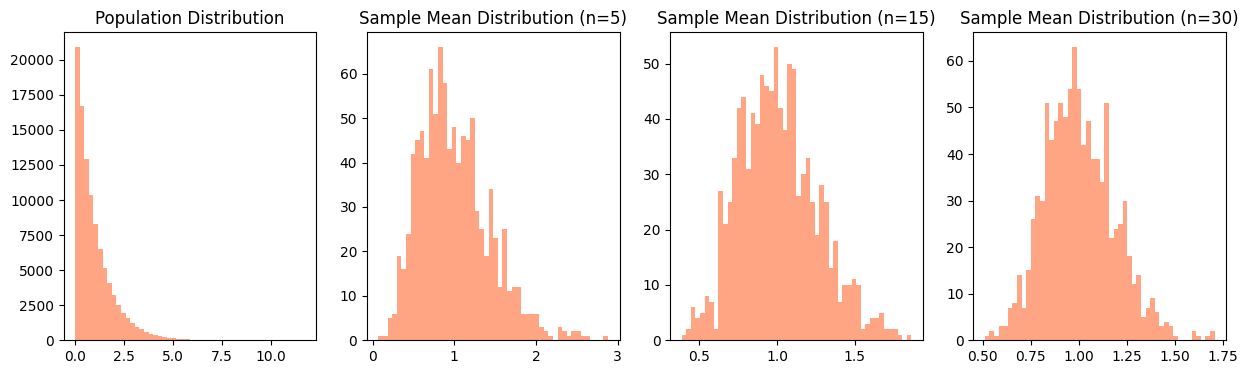

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
population = np.random.exponential(size=100000)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].hist(population, bins=50, color='coral', alpha=0.7)
axes[0].set_title('Population Distribution')

sample_mean_n5 = [np.mean(np.random.choice(population, 5)) for _ in range(1000)]
axes[1].hist(sample_mean_n5, bins=50, color='coral', alpha=0.7)
axes[1].set_title('Sample Mean Distribution (n=5)')

sample_mean_n15 = [np.mean(np.random.choice(population, 15)) for _ in range(1000)]
axes[2].hist(sample_mean_n15, bins=50, color='coral', alpha=0.7)
axes[2].set_title('Sample Mean Distribution (n=15)')

sample_mean_n30 = [np.mean(np.random.choice(population, 30)) for _ in range(1000)]
axes[3].hist(sample_mean_n30, bins=50, color='coral', alpha=0.7)
axes[3].set_title('Sample Mean Distribution (n=30)')


## 4. **Day-4** *(Hypothesis Testing & Correlation)*

**Task:** Load the Titanic dataset. Run a two-sample t-test comparing the ages of survivors vs.
non-survivors. State your H0 and H1 clearly. Interpret the p-value and conclude. Then compute
the Pearson and Spearman correlation between Age and Fare. Discuss why they might differ.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("/content/Titanic-Dataset.csv")

print("Null Hypothesis: No significant age difference between groups")
print("Alternative Hypothesis: Age DOES differ significantly between survivors and non-survivors")

survivors = df[df['Survived']==1]['Age'].dropna()
non_survivors = df[df['Survived']==0]['Age'].dropna()

t_stat, p_value = stats.ttest_ind(survivors, non_survivors, equal_var=False)

print(f"\nt_statistic: {t_stat:.3f}")
print(f"p_value: {p_value:.4f}")

print("\nConclusion:")

alpha = 0.05
if p_value < alpha:
  print("\nAge DOES differ significantly between survivors and non-survivors")
else:
  print("\nNo significant age difference between groups")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Titanic-Dataset.csv'

In [ ]:
# Correlation analysis
df_filtered = df[['Age', 'Fare']].dropna()
age = df_filtered['Age']
fare = df_filtered['Fare']

r_pearson, p_pearson = stats.pearsonr(age, fare)
print(f'Pearson r = {r_pearson:.3f}, p = {p_pearson:.4f}')

r_spearman, p_spearman = stats.spearmanr(age, fare)
print(f'Spearman r = {r_spearman:.3f}, p = {p_spearman:.4f}')

Pearson r = 0.096, p = 0.0102
Spearman r = 0.135, p = 0.0003


**Note:** The low p values suggests a very weak relation between `Age` & `Fare`

Text(0, 0.5, 'Fare')

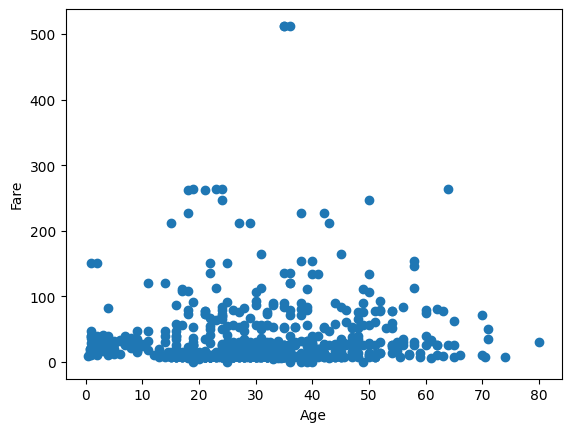

In [ ]:
plt.scatter(age, fare)
plt.xlabel('Age')
plt.ylabel('Fare')

## 5. **Day-5** *(Data Wrangling with Pandas)*

**Task:** Load the Titanic dataset. (1) Profile it: check shape, dtypes, and null counts. (2) Handle all
missing values — use median for Age, mode for Embarked, and drop Cabin. (3) Run a GroupBy
to compare survival rates by Pclass. (4) Find the top 5 most expensive tickets using sort_values.

In [ ]:
import numpy as np
import pandas as pd

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}\n")
print(f"Dtypes: {df.dtypes}\n")
print(f"Null counts (Before): {df.isnull().sum()}\n")

# Handling Missing Values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

print(f"Null counts (After): {df.isnull().sum()}\n")

Shape: (891, 12)

Dtypes: PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Null counts (Before): PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Null counts (After): PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64



In [ ]:
# Using Groupby
survival_rate_by_class = df.groupby('Pclass')['Survived'].mean()
print(f"Survival rate by class: {survival_rate_by_class}\n")


Survival rate by class: Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64



In [ ]:
# Checking
print(df['Pclass'].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [ ]:
# Ticket Cost
ticket_sorted_df = df.sort_values('Fare', ascending=False)
cols = ['Name', 'Pclass', 'Fare', 'Survived']
print("5 Most Expensive Tickets: ")
print(ticket_sorted_df[cols].head(5).to_string(index=False))

5 Most Expensive Tickets: 
                              Name  Pclass     Fare  Survived
Cardeza, Mr. Thomas Drake Martinez       1 512.3292         1
                  Ward, Miss. Anna       1 512.3292         1
            Lesurer, Mr. Gustave J       1 512.3292         1
        Fortune, Miss. Mabel Helen       1 263.0000         1
                 Fortune, Mr. Mark       1 263.0000         0


#6. **Day-6** *(Data Visualization — Univariate Analysis)*

**Task:** Load the Titanic dataset. (1) Plot the Age distribution using both histogram (bins=20) and KDE
on the same figure. (2) Create a box plot for the Fare column — note the outliers. Apply log
transformation and re-plot. (3) Create a count plot for the Embarked column. Write 2–3
observations under each chart.

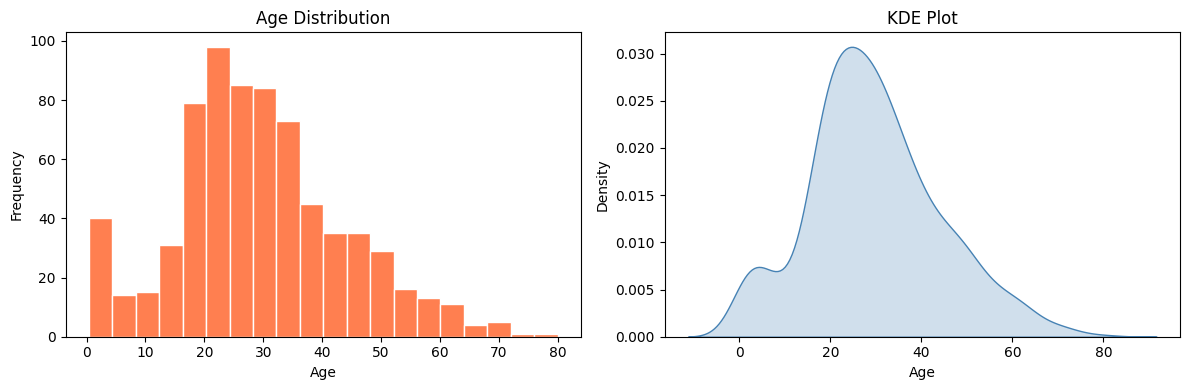

In [ ]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Histogram & KDE plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Age'], bins=20, color='coral', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

sns.kdeplot(df['Age'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('KDE Plot')
axes[1].set_xlabel('Age')
axes[1].set_title('KDE Plot')
plt.tight_layout()
plt.show()

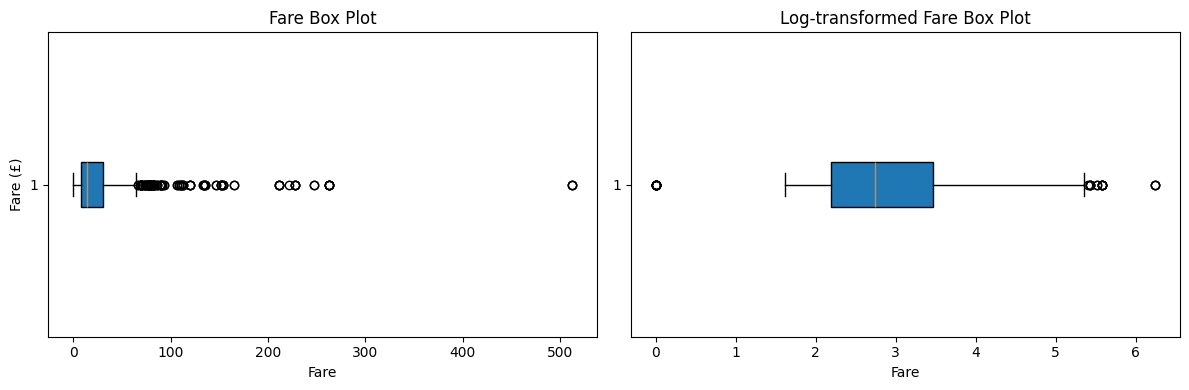

In [ ]:
# Box plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Fare'].dropna(), patch_artist=True,
                vert=False
                )
axes[0].set_title('Fare Box Plot')
axes[0].set_ylabel('Fare (£)')
axes[0].set_xlabel('Fare')

axes[1].boxplot(np.log1p(df['Fare'].dropna()), patch_artist=True,
                vert=False
                )
axes[1].set_title('Log-transformed Fare Box Plot')
axes[1].set_xlabel('Fare')
plt.tight_layout()
plt.show()

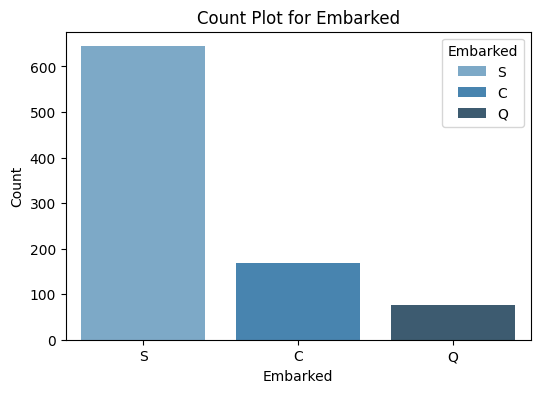

In [ ]:
# Count plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Embarked', data=df, palette='Blues_d',
              hue='Embarked'
              )
plt.title('Count Plot for Embarked')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.show()